In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, TensorDataset


################
import pandas as pd

In [ ]:
########### parameters ###################
seq_length = 32
batch_size = 32
features = 10
n_embd = 512
n_head = 8
n_layer = 4
epochs = 50
#forecast_horizon = 7

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
daily_returns_df = pd.read_csv('/content/daily_returns_US.csv')
daily_returns_df.head()

,Date,AAPL,AMZN,CAT,DOW,GOOGL,JNJ,JPM,MSFT,WMT,XOM
0,2021-04-06 00:00:00,0.002462,-0.000902,-0.013136,0.000155,-0.004371,-0.000244,-0.007030,-0.004858,0.004805,-0.002832
1,2021-04-07 00:00:00,0.013391,0.017237,-0.000997,-0.009442,0.013475,0.001346,0.015668,0.008230,-0.002141,0.004437
2,2021-04-08 00:00:00,0.019234,0.006071,0.000304,-0.012502,0.005091,-0.003912,0.001226,0.013405,-0.000644,-0.010426
3,2021-04-09 00:00:00,0.020252,0.022096,0.001172,-0.000791,0.008994,-0.010554,0.007478,0.010267,0.000501,-0.002321
4,2021-04-12 00:00:00,-0.013233,0.002132,0.000780,0.010295,-0.011472,0.002418,-0.002112,0.000235,0.000143,-0.006623


In [ ]:
daily_returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1255 non-null   object 
 1   AAPL    1255 non-null   float64
 2   AMZN    1255 non-null   float64
 3   CAT     1255 non-null   float64
 4   DOW     1255 non-null   float64
 5   GOOGL   1255 non-null   float64
 6   JNJ     1255 non-null   float64
 7   JPM     1255 non-null   float64
 8   MSFT    1255 non-null   float64
 9   WMT     1255 non-null   float64
 10  XOM     1255 non-null   float64
dtypes: float64(10), object(1)
memory usage: 108.0+ KB


In [ ]:
daily_returns_df = daily_returns_df.drop(['Date'],axis=1)
daily_returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1255 non-null   float64
 1   AMZN    1255 non-null   float64
 2   CAT     1255 non-null   float64
 3   DOW     1255 non-null   float64
 4   GOOGL   1255 non-null   float64
 5   JNJ     1255 non-null   float64
 6   JPM     1255 non-null   float64
 7   MSFT    1255 non-null   float64
 8   WMT     1255 non-null   float64
 9   XOM     1255 non-null   float64
dtypes: float64(10)
memory usage: 98.2 KB


In [ ]:
df_np = daily_returns_df.to_numpy()



In [ ]:
df_np.shape

(1255, 10)

In [ ]:
from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#df_np = scaler.fit_transform(df_np)

In [ ]:
n = int(0.7 * len(df_np) )
n

878

In [ ]:
Train_data = df_np[:n]
Test_data = df_np[n:]

In [ ]:
mean = Train_data.mean(axis=0)
std = Train_data.std(axis=0)

In [ ]:
print(Train_data.shape)
print(Test_data.shape)

(878, 10)
(377, 10)


In [ ]:
def make_dataset(data, seq_length):
    x = []
    y = []
    for i in range(len(data)-seq_length):
        _x = data[i:(i+seq_length)]
        _y = data[i+1:(i+seq_length+1)]
        x.append(_x)
        y.append(_y)
    return np.array(x), np.array(y)

In [ ]:
def make_dataset(data, seq_length):
    x = []
    y = []
    for i in range(len(data)-seq_length):
        _x = data[i:(i+seq_length)]
        _y = data[i+1:(i+seq_length+1)]
        x.append(_x)
        y.append(_y)
    return np.array(x), np.array(y)

In [ ]:
x_train, y_train = make_dataset(Train_data, seq_length)
x_test, y_test = make_dataset(Test_data, seq_length)

In [ ]:
print("x_train shape:",x_train.shape)
print("y_train shape:",y_train.shape)
print("x_test shape:",x_test.shape)
print("y_test shape:",y_test.shape)

x_train shape: (846, 32, 10)
y_train shape: (846, 32, 10)
x_test shape: (345, 32, 10)
y_test shape: (345, 32, 10)


In [ ]:
########## convert to tensor and setting datatype to avoid datamismatch error ########
x_train = torch.tensor(x_train,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.float32)

y_test = torch.tensor(y_test,dtype=torch.float32)
x_test = torch.tensor(x_test,dtype=torch.float32)

In [ ]:
###### dataloading ########################
dataset_train = TensorDataset(x_train,y_train)
train_loader = DataLoader(dataset_train,batch_size=batch_size,shuffle=True)


In [ ]:
class Head(nn.Module):

    def __init__(self, head_size):
        super().__init__()

        self.key = nn.Linear(n_embd,head_size,bias=False)
        self.query = nn.Linear(n_embd,head_size,bias=False)
        self.value = nn.Linear(n_embd,head_size,bias=False)
        self.dropout = nn.Dropout(0.2)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(seq_length,seq_length))
        )

    def forward(self,x):

        B,T,E = x.shape

        k = self.key(x)
        q = self.query(x)

        wei = q @ k.transpose(-2,-1) * (k.shape[-1] ** -0.5)

        wei = wei.masked_fill(
            self.tril[:T,:T]==0,
            float('-inf')
        )

        wei = F.softmax(wei,dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)

        return wei @ v

In [ ]:
class MultiHead(nn.Module):

    def __init__(self):
        super().__init__()

        head_size = n_embd // n_head

        self.heads = nn.ModuleList(
            [Head(head_size) for _ in range(n_head)]
        )
        self.dropout = nn.Dropout(0.2)
        self.proj = nn.Linear(n_embd,n_embd)

    def forward(self,x):

        x = torch.cat([h(x) for h in self.heads],dim=-1)
        x = self.proj(x)

        return self.dropout(x)

In [ ]:
class FeedForward(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd,4*n_embd),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(4*n_embd,n_embd),
            nn.Dropout(0.2)
        )

    def forward(self,x):
        return self.net(x)

In [ ]:
class Block(nn.Module):

    def __init__(self):
        super().__init__()

        self.sa = MultiHead()
        self.ff = FeedForward()

        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self,x):

        x = x + self.sa(self.ln1(x))
        x = x + self.ff(self.ln2(x))

        return x

In [ ]:
class CNNEmbedding(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=features, out_channels=128, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv1d(in_channels=128, out_channels=n_embd, kernel_size=3, padding=1),
            nn.GELU()
        )

    def forward(self, x):
        # x: (B, T, F)

        x = x.permute(0, 2, 1)   # (B, F, T)
        x = self.conv(x)         # (B, n_embd, T)
        x = x.permute(0, 2, 1)   # (B, T, n_embd)

        return x

In [ ]:
# ============================================================
# TIME SERIES GPT
# ============================================================

class TimeSeriesGPT(nn.Module):

    def __init__(self, mean, std ):
        super().__init__()

        self.embedding = CNNEmbedding()

        self.pos_emb = nn.Embedding(seq_length,n_embd)

        self.blocks = nn.Sequential(
            *[Block() for _ in range(n_layer)]
        )

        self.ln = nn.LayerNorm(n_embd)

        self.head = nn.Linear(n_embd,features)

        self.register_buffer('mean',torch.tensor(mean,dtype=torch.float32))
        self.register_buffer('std',torch.tensor(std,dtype=torch.float32))

    def forward(self, x):

      B, T, F = x.shape

      # =========================
      # NORMALIZATION
      # =========================
      mean = self.mean.view(1, 1, -1)
      std  = self.std.view(1, 1, -1)

      x = (x - mean) / (std + 1e-8)

      # =========================
      # MODEL
      # =========================
      x = self.embedding(x)

      pos = torch.arange(T, device=x.device)
      x = x + self.pos_emb(pos)

      x = self.blocks(x)
      x = self.ln(x)

      #x = x[:, -1, :]   # (B, n_embd)


      out = self.head(x)  # (B, features * horizon)

      #out = out.view(B, forecast_horizon, F)  # (B, horizon, F)

      # =========================
      # DENORMALIZE
      # =========================
      out = out * (std + 1e-8) + mean

      return out

In [ ]:
model = TimeSeriesGPT(mean,std).to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=3e-4)

In [ ]:
# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for xb,yb in train_loader:

        xb=xb.to(device)
        yb=yb.to(device)
       #print(xb.shape)
       # print(yb.shape)
        #input()
        pred = model(xb)

        #loss = F.mse_loss(pred,yb)
        loss = F.smooth_l1_loss(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("epoch",epoch,"loss",total_loss/len(train_loader))

epoch 0 loss 1.1708405509125441e-05
epoch 1 loss 1.0037258949456305e-05
epoch 2 loss 9.087335692365067e-06
epoch 3 loss 8.372879485115711e-06
epoch 4 loss 7.923390512587503e-06
epoch 5 loss 7.596426611497817e-06
epoch 6 loss 7.216027336619811e-06
epoch 7 loss 7.041986952605873e-06
epoch 8 loss 6.7914050945277e-06
epoch 9 loss 6.651161112569281e-06
epoch 10 loss 6.5465862833123e-06
epoch 11 loss 6.333954001160304e-06
epoch 12 loss 6.189963153667998e-06
epoch 13 loss 6.0830511756648775e-06
epoch 14 loss 6.004585749771515e-06
epoch 15 loss 5.879007470934151e-06
epoch 16 loss 5.796723161000517e-06
epoch 17 loss 5.949389122650717e-06
epoch 18 loss 5.791604811141345e-06
epoch 19 loss 5.63442037875777e-06
epoch 20 loss 5.593792374619861e-06
epoch 21 loss 5.5380446947647554e-06
epoch 22 loss 5.51651970050039e-06
epoch 23 loss 5.426148483685985e-06
epoch 24 loss 5.414310214325303e-06
epoch 25 loss 5.443200212472153e-06
epoch 26 loss 5.346778152670595e-06
epoch 27 loss 5.277138395993259e-06
epoc

In [ ]:
# ============================================================
# TEST EVALUATION
# ============================================================

model.eval()

with torch.no_grad():

    xb = x_test.to(device)

    pred = model(xb).cpu().numpy()

    true = y_test.numpy()

In [ ]:
true = y_test.numpy()   # (N, 30, 10)
pred = model(x_test.to(device)).detach().cpu().numpy()

In [ ]:
stock_names = ["AAPL", "AMZN", "CAT", "DOW", "GOOGL", "JNJ", "JPM", "MSFT", "WMT", "XOM"]

In [ ]:
mse = np.mean((pred-true)**2)

r2 = r2_score(
    true.reshape(-1,features),
    pred.reshape(-1,features)
)

print("Test MSE:",mse)
print("Test R2 :",r2)

Test MSE: 2.851036e-05
Test R2 : 0.9228774905204773


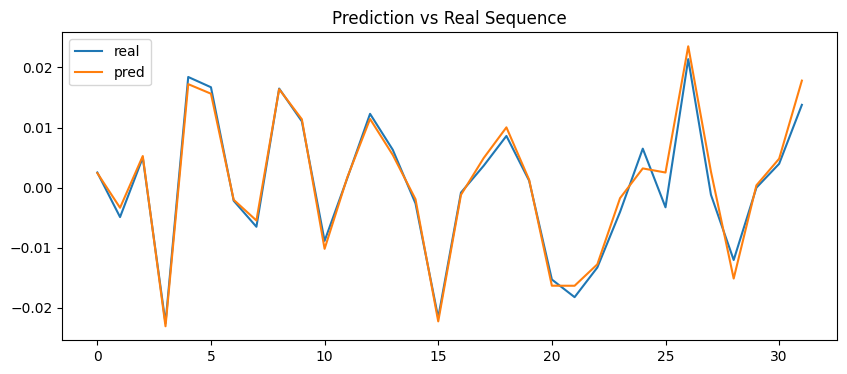

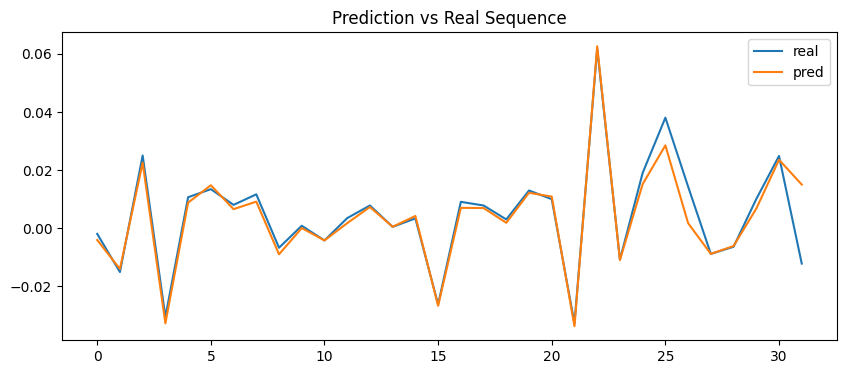

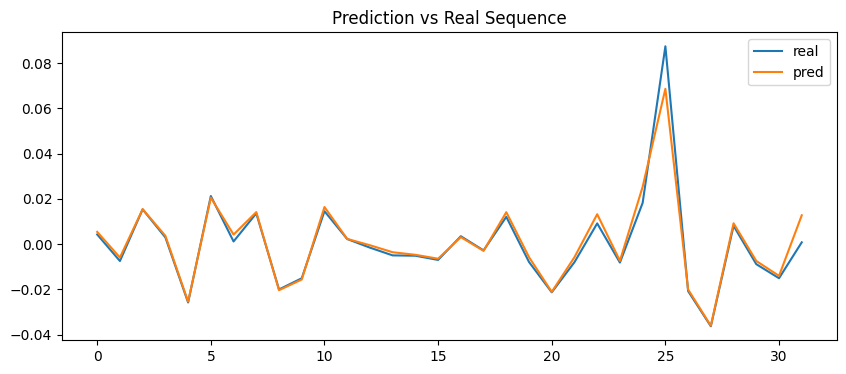

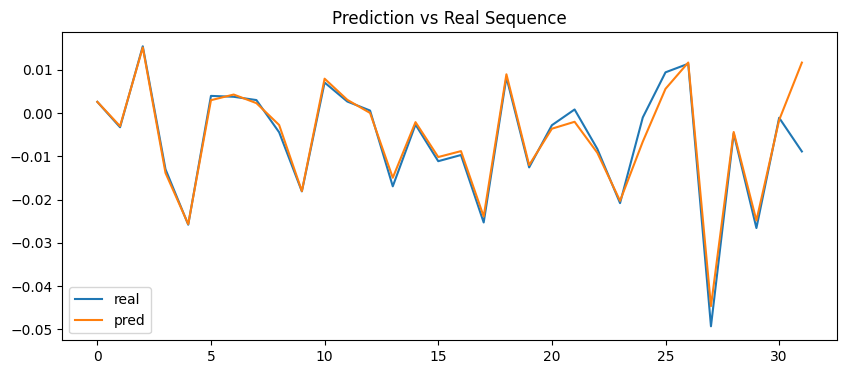

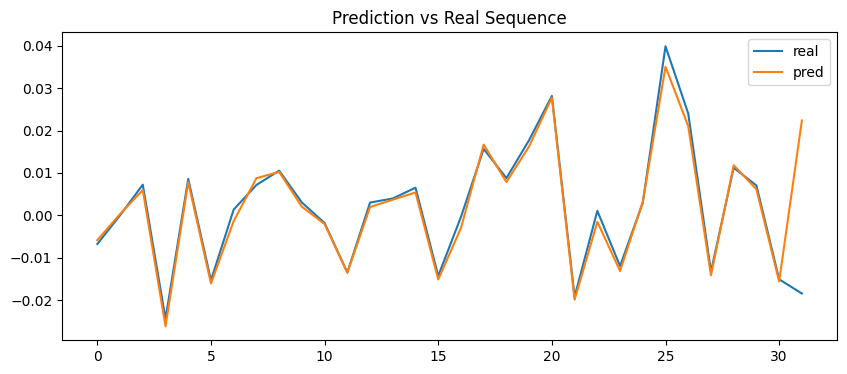

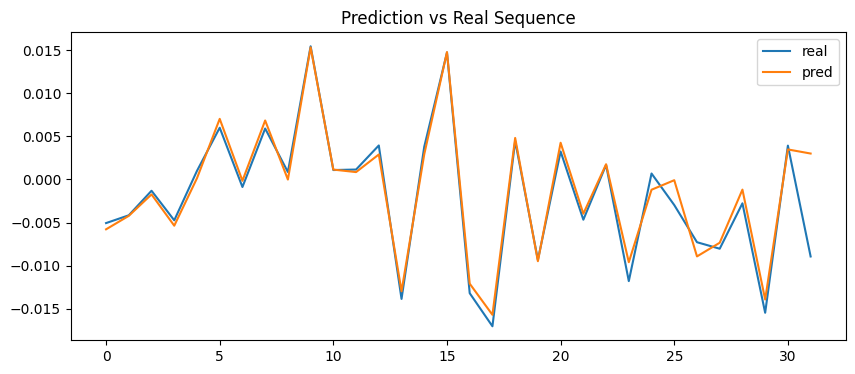

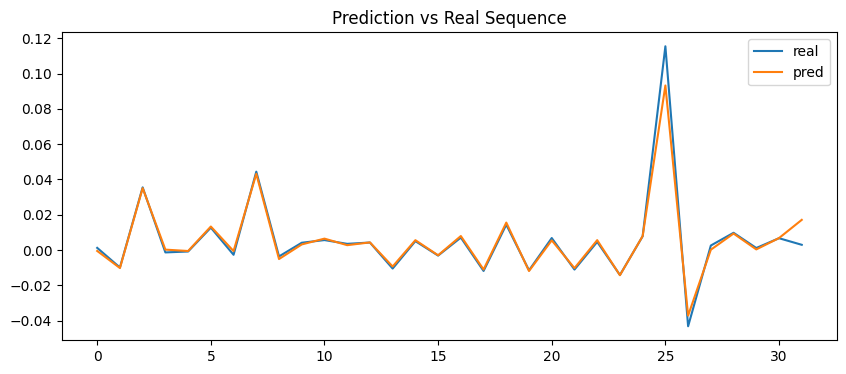

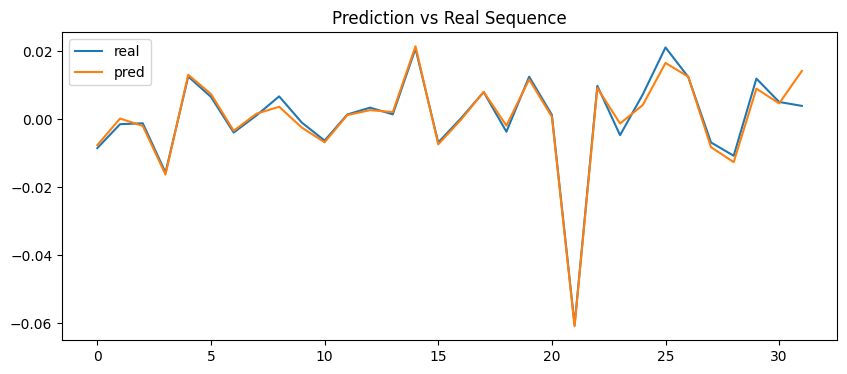

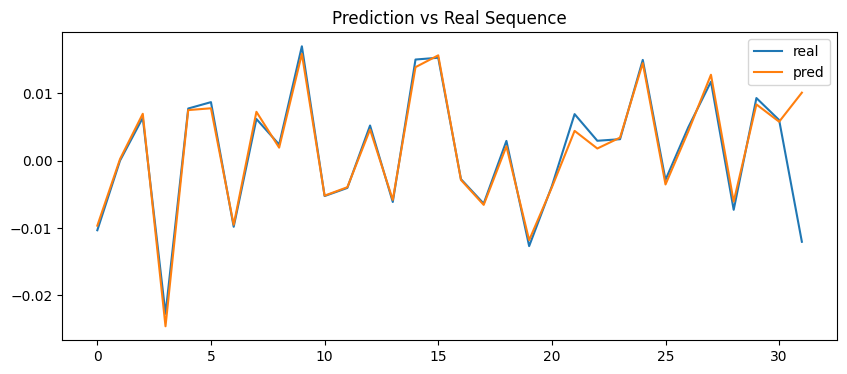

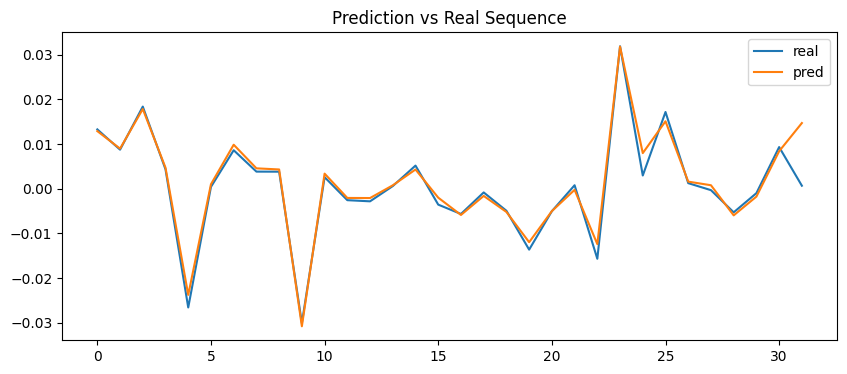

In [ ]:
# ============================================================
# PLOT PREDICTED VS REAL
# ============================================================
for feature_id in range (10):

  plt.figure(figsize=(10,4))

  plt.plot(true[0,:,feature_id],label="real")

  plt.plot(pred[0,:,feature_id],label="pred")

  plt.legend()

  plt.title("Prediction vs Real Sequence")

  plt.show()

In [ ]:
import matplotlib.pyplot as plt

seq_idx = -1  # last test sample (most realistic)

true_seq = true[seq_idx]   # (30, 10)
pred_seq = pred[seq_idx]   # (30, 10)

days = range(1, 8)

for i, name in enumerate(stock_names):

    plt.figure(figsize=(10,4))

    plt.plot(days, true_seq[:, i], label="Real")
    plt.plot(days, pred_seq[:, i], label="Pred")

    plt.title(f"{name} - 30 Day Forecast")
    plt.xlabel("Days Ahead")
    plt.ylabel("Returns")

    plt.legend()
    plt.show()

In [ ]:
direction_acc = np.mean(
    np.sign(true_seq) == np.sign(pred_seq)
)

print("Direction Accuracy:", direction_acc)

In [ ]:
corr = np.corrcoef(
    true_seq.flatten(),
    pred_seq.flatten()
)[0,1]

print("Correlation:", corr)

In [ ]:
real_cum = np.cumsum(true_seq[:, 0])   # AAPL
pred_cum = np.cumsum(pred_seq[:, 0])

plt.figure(figsize=(10,4))
plt.plot(real_cum, label="Real")
plt.plot(pred_cum, label="Pred")
plt.title("AAPL - Cumulative Returns (30 days)")
plt.legend()
plt.show()

In [ ]:
def sequential_forecast(
    model,
    x_test,
    y_test,
    stock_names,
    device,
    seq_index=0,
    forecast_steps=30,
    plot=True
):
    """
    Perform sequential (auto-regressive) forecasting.

    Args:
        model: trained model
        x_test: input sequences (N, T, F)
        y_test: target sequences (N, T, F)
        stock_names: list of company names
        device: torch device
        seq_index: which test sequence to start from
        forecast_steps: number of future steps to predict
        plot: whether to plot results

    Returns:
        pred_seq: predicted sequence (forecast_steps, F)
        true_seq: actual sequence (forecast_steps, F)
    """

    model.eval()

    # =========================
    # 1. Get initial sequence
    # =========================
    init_seq = x_test[seq_index].unsqueeze(0).to(device)  # (1, T, F)

    current_seq = init_seq.clone()
    predictions = []

    # =========================
    # 2. Sequential prediction
    # =========================
    for _ in range(forecast_steps):

        with torch.no_grad():
            out = model(current_seq)  # (1, T, F)

        next_step = out[:, -1, :]  # last timestep (1, F)

        predictions.append(next_step.cpu().numpy())

        # update sequence (shift left + append new prediction)
        next_step = next_step.unsqueeze(1)  # (1,1,F)
        current_seq = torch.cat(
            [current_seq[:, 1:, :], next_step],
            dim=1
        )

    # =========================
    # 3. Convert predictions
    # =========================
    pred_seq = np.vstack(predictions)  # (steps, F)

    # =========================
    # 4. Get real values
    # =========================
    true_seq = y_test[seq_index][:forecast_steps].numpy()

    # =========================
    # 5. Plot
    # =========================
    if plot:
        for i, name in enumerate(stock_names):

            plt.figure(figsize=(10,4))

            plt.plot(true_seq[:, i], label="Real")
            plt.plot(pred_seq[:, i], label="Pred")

            plt.title(f"{name} - Sequential Forecast ({forecast_steps} days)")
            plt.xlabel("Time Step")
            plt.ylabel("Returns")

            plt.legend()
            plt.show()

    return pred_seq, true_seq

In [ ]:
pred_seq, true_seq = sequential_forecast(
    model=model,
    x_test=x_test,
    y_test=y_test,
    stock_names=stock_names,
    device=device,
    seq_index=0,
    forecast_steps=30
)

In [ ]:
pred.shape

(345, 32, 10)

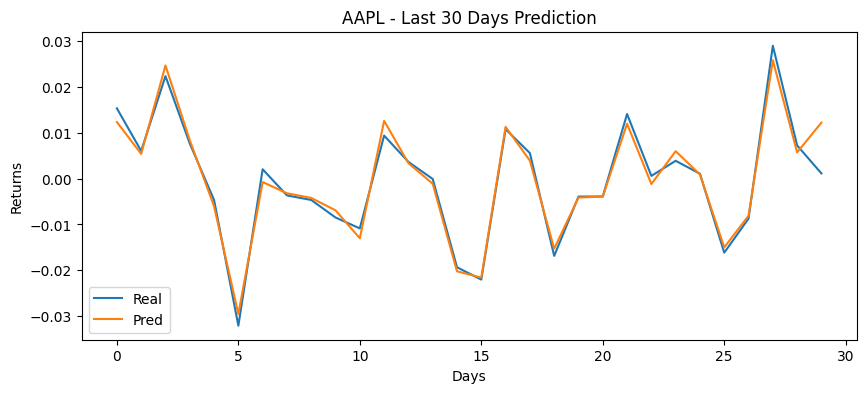

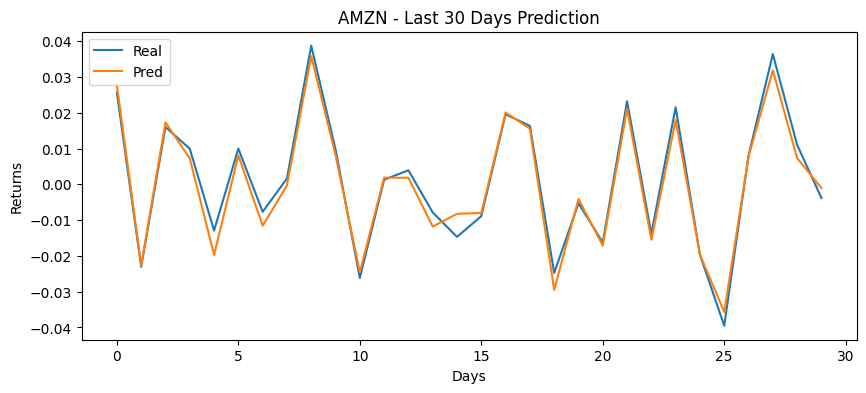

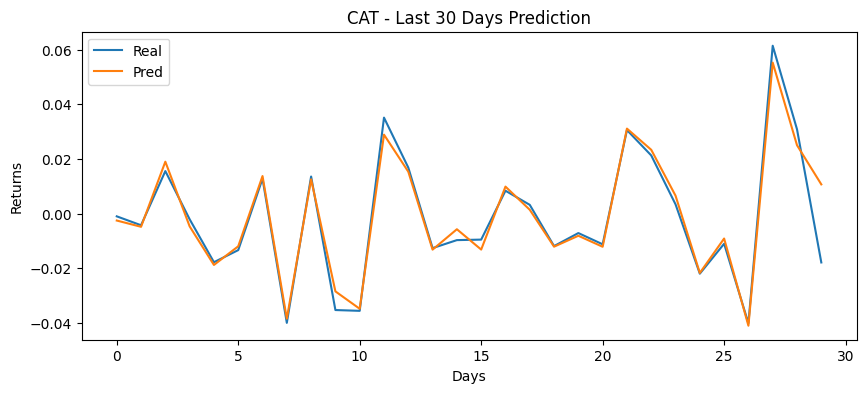

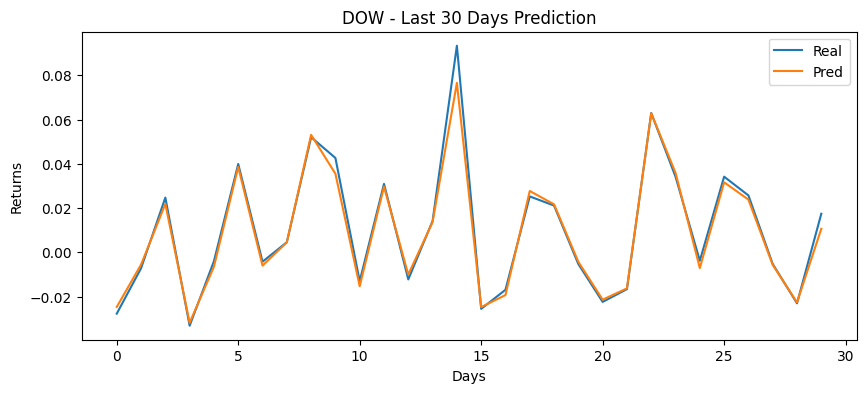

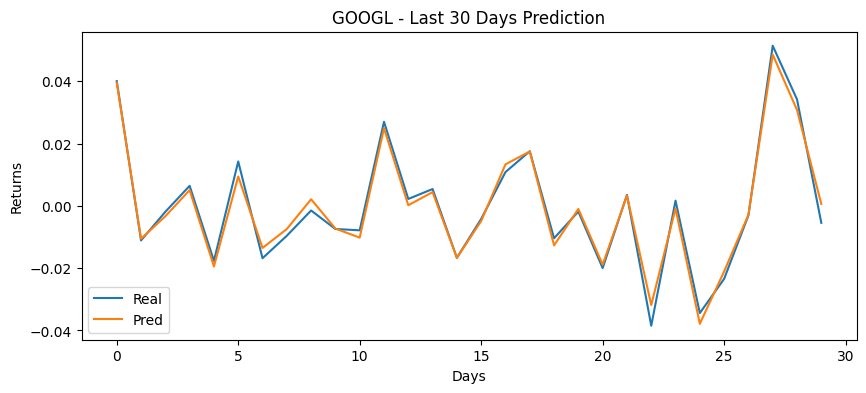

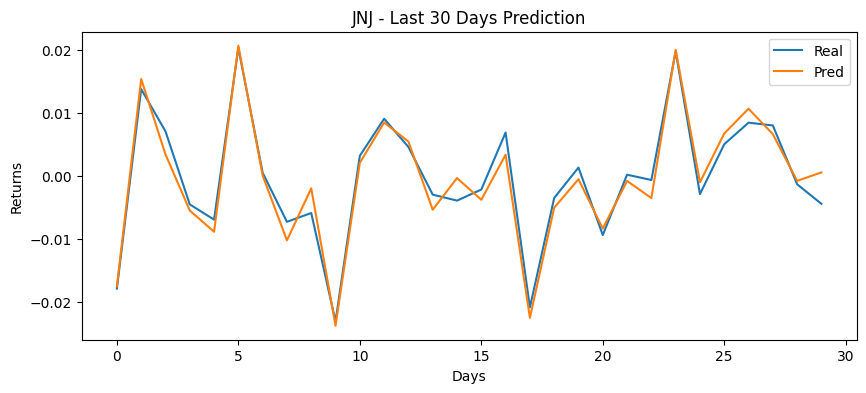

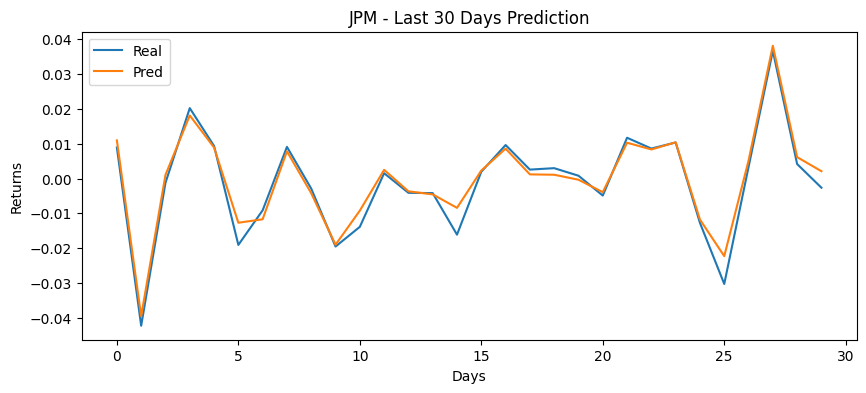

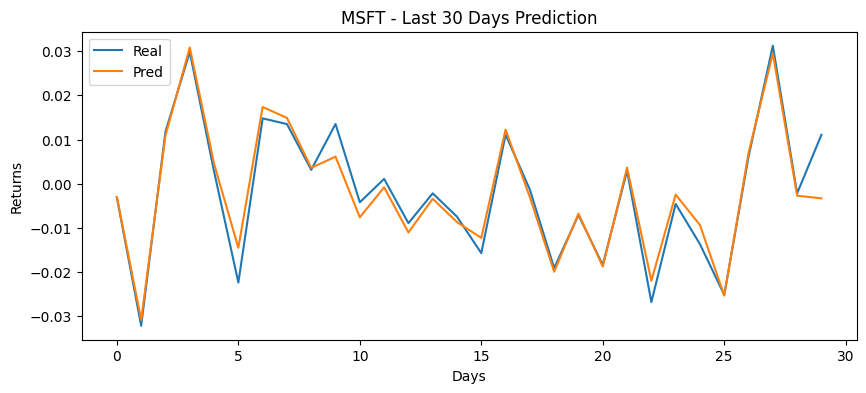

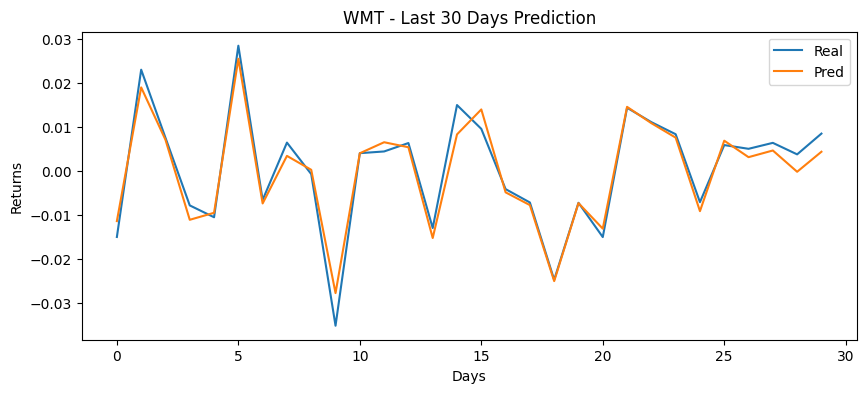

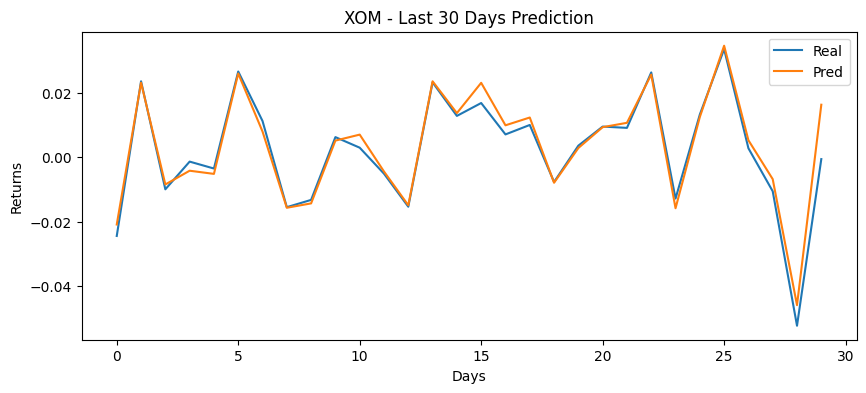

In [ ]:
real_flat = true.reshape(-1, 10)
pred_flat = pred.reshape(-1, 10)

for i, name in enumerate(stock_names):

    plt.figure(figsize=(10,4))

    plt.plot(real_flat[-30:, i], label="Real")
    plt.plot(pred_flat[-30:, i], label="Pred")

    plt.legend()
    plt.title(f"{name} - Last 30 Days Prediction")

    plt.xlabel("Days")
    plt.ylabel("Returns")

    plt.show()

In [ ]:
# 🔥 Put model in eval mode
model.eval()

# 🔥 Move to CPU (IMPORTANT for portability)
model.cpu()

# 🔥 Dummy input (MUST match your model input shape)
dummy_input = torch.randn(1, 30, 10)

# 🔥 Convert to TorchScript (use TRACE)
scripted_model = torch.jit.trace(model, dummy_input)

# 🔥 Save model
scripted_model.save("timeseries_model_scripted.pt")

print("✅ TorchScript model saved!")

✅ TorchScript model saved!
